In [1]:
import pandas as pd

df = pd.read_csv("ecommerce_dataset.csv")

df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


In [3]:
df.shape

(3660, 8)

In [4]:
df.isnull().sum()

User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Purchase_Date'] = pd.to_datetime(
    df['Purchase_Date'],
    dayfirst=True
)

In [26]:
df['Year'] = df['Purchase_Date'].dt.year
df['Month'] = df['Purchase_Date'].dt.month_name()

# Revenue Analysis

## Total Revenue

In [14]:
total_revenue = df['Final_Price(Rs.)'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 757278.08


## Average Order Value (AOV)

In [16]:
avg_order_value = df['Final_Price(Rs.)'].mean()

print("Average Order Value:", round(avg_order_value,2))

Average Order Value: 206.91


## Unique Customers

In [17]:
unique_customers = df['User_ID'].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 3660


## Total Orders

In [18]:
total_orders = len(df)

print("Total Orders:", total_orders)

Total Orders: 3660


## Revenue by Category

In [19]:
category_sales = (
    df.groupby('Category')['Final_Price(Rs.)']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Clothing          115314.84
Books             111149.35
Home & Kitchen    110328.08
Sports            108518.79
Toys              107289.69
Beauty            104215.10
Electronics       100462.23
Name: Final_Price(Rs.), dtype: float64


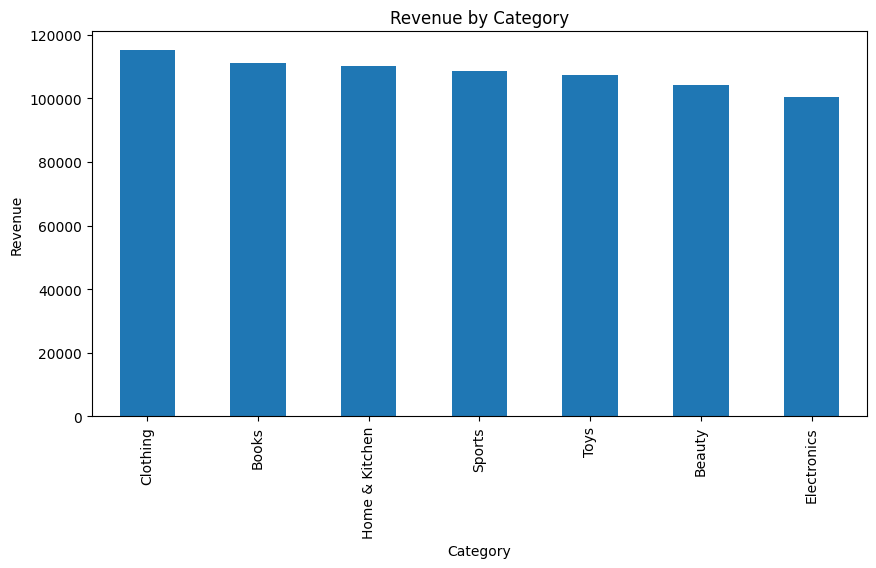

In [20]:
import matplotlib.pyplot as plt

category_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

## Revenue Trend by Month

In [21]:
monthly_sales = (
    df.groupby('Month')['Final_Price(Rs.)']
    .sum()
)

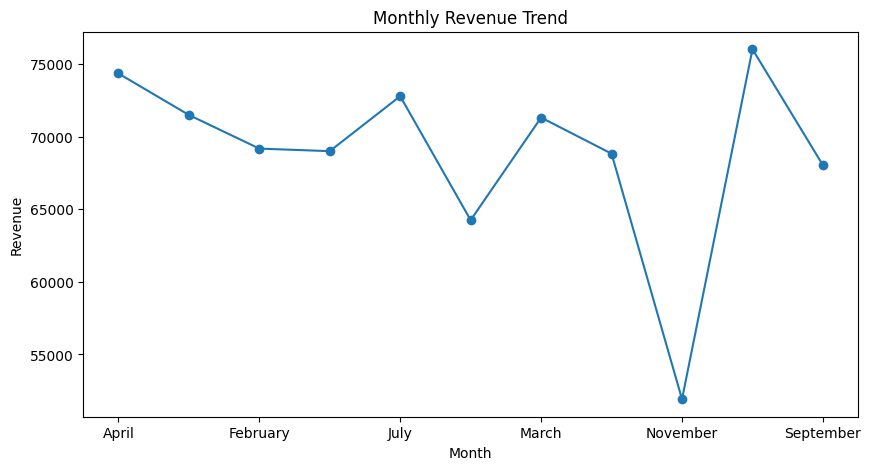

In [22]:
monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

## Top 10 Products

In [28]:
top_products = (
    df.groupby('Product_ID')['Final_Price(Rs.)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product_ID
5a4c2797-7    496.82
2a8fff8b-4    495.02
475d4cf1-c    493.04
e88dc97f-5    492.41
67d7c91c-b    491.70
128bb94a-4    487.06
28714133-6    486.79
585b0773-2    484.56
3be497cb-0    480.49
6390f2ea-8    479.63
Name: Final_Price(Rs.), dtype: float64


# Customer & Discount Analytics

## Top 10 Customers by Spending

In [29]:
top_customers = (
    df.groupby('User_ID')['Final_Price(Rs.)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

User_ID
8b885340    496.82
20797b76    495.02
d8970dd2    493.04
da7bc76a    492.41
68722b9b    491.70
05e6557c    487.06
67abda0a    486.79
d646700c    484.56
edb89577    480.49
f9e89622    479.63
Name: Final_Price(Rs.), dtype: float64


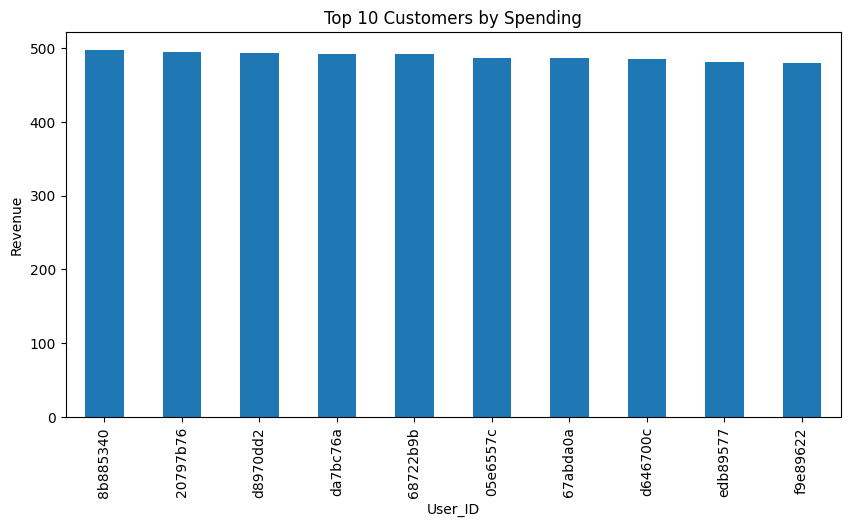

In [30]:
top_customers.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Customers by Spending")
plt.ylabel("Revenue")
plt.show()

## Customer Purchase Frequency

In [31]:
purchase_frequency = (
    df.groupby('User_ID')
    .size()
    .sort_values(ascending=False)
)

print(purchase_frequency.head(10))

User_ID
001ae40d    1
00209791    1
0021e458    1
00333c7a    1
00390cf5    1
0041710c    1
0049cde2    1
005258a0    1
007d82ed    1
00812bf1    1
dtype: int64


## Customer Segmentation

In [32]:
customer_orders = df.groupby('User_ID').size()

def segment(x):
    if x == 1:
        return "One-Time Buyer"
    elif x <= 3:
        return "Repeat Buyer"
    else:
        return "VIP Customer"

customer_segment = customer_orders.apply(segment)

print(customer_segment.value_counts())

One-Time Buyer    3660
Name: count, dtype: int64


## Average Discount

In [34]:
avg_discount = df['Discount (%)'].mean()

print("Average Discount:", round(avg_discount,2))

Average Discount: 18.83


## Category-wise Discount Analysis

In [35]:
category_discount = (
    df.groupby('Category')['Discount (%)']
    .mean()
    .sort_values(ascending=False)
)

print(category_discount)

Category
Home & Kitchen    19.608379
Sports            19.326923
Electronics       19.267068
Books             19.035581
Beauty            18.475248
Toys              18.126195
Clothing          17.919021
Name: Discount (%), dtype: float64


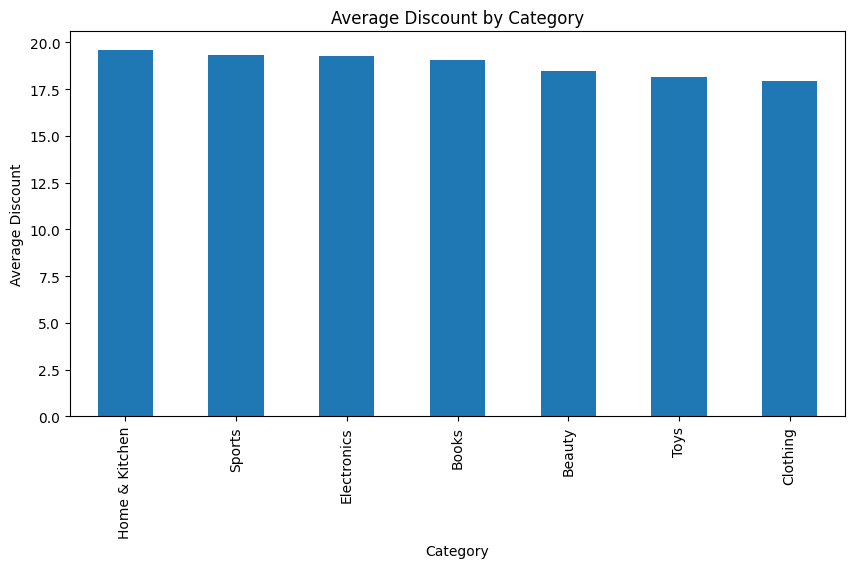

In [36]:
category_discount.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Discount by Category")
plt.ylabel("Average Discount")
plt.show()

## Revenue vs Discount Relationship

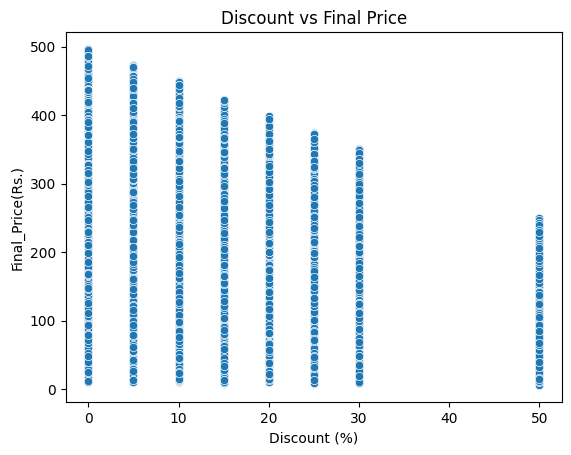

In [38]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x='Discount (%)',
    y='Final_Price(Rs.)'
)

plt.title("Discount vs Final Price")
plt.show()

## Most Used Payment Method

In [39]:
payment_count = df['Payment_Method'].value_counts()

print(payment_count)

Payment_Method
Credit Card         760
UPI                 757
Debit Card          731
Net Banking         716
Cash on Delivery    696
Name: count, dtype: int64


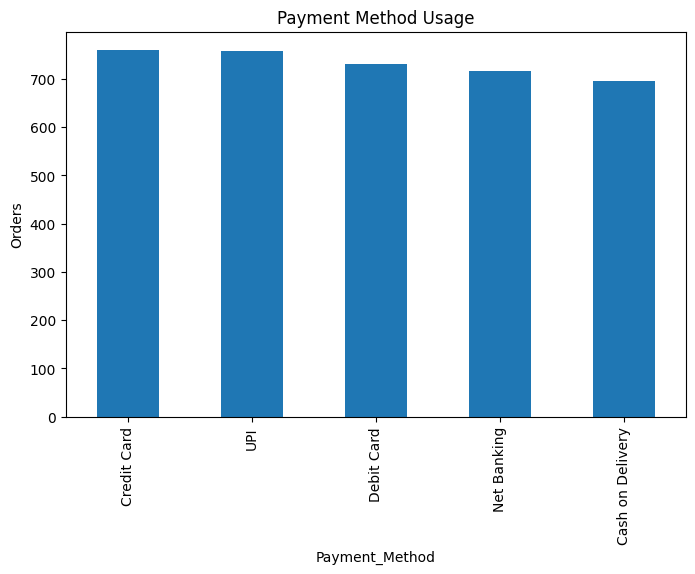

In [40]:
payment_count.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Payment Method Usage")
plt.ylabel("Orders")
plt.show()

## Revenue by Payment Method

In [41]:
payment_revenue = (
    df.groupby('Payment_Method')['Final_Price(Rs.)']
    .sum()
    .sort_values(ascending=False)
)

print(payment_revenue)

Payment_Method
Credit Card         156018.02
UPI                 154684.81
Debit Card          153362.26
Net Banking         146804.40
Cash on Delivery    146408.59
Name: Final_Price(Rs.), dtype: float64


## Average Order Value by Payment Method

In [42]:
payment_aov = (
    df.groupby('Payment_Method')['Final_Price(Rs.)']
    .mean()
    .sort_values(ascending=False)
)

print(payment_aov)

Payment_Method
Cash on Delivery    210.357170
Debit Card          209.797893
Credit Card         205.286868
Net Banking         205.034078
UPI                 204.339247
Name: Final_Price(Rs.), dtype: float64


# PRODUCT & CATEGORY PERFORMANCE ANALYSIS

## Orders by Category

In [43]:
category_orders = (
    df['Category']
    .value_counts()
)

print(category_orders)

Category
Home & Kitchen    549
Books             534
Clothing          531
Toys              523
Sports            520
Beauty            505
Electronics       498
Name: count, dtype: int64


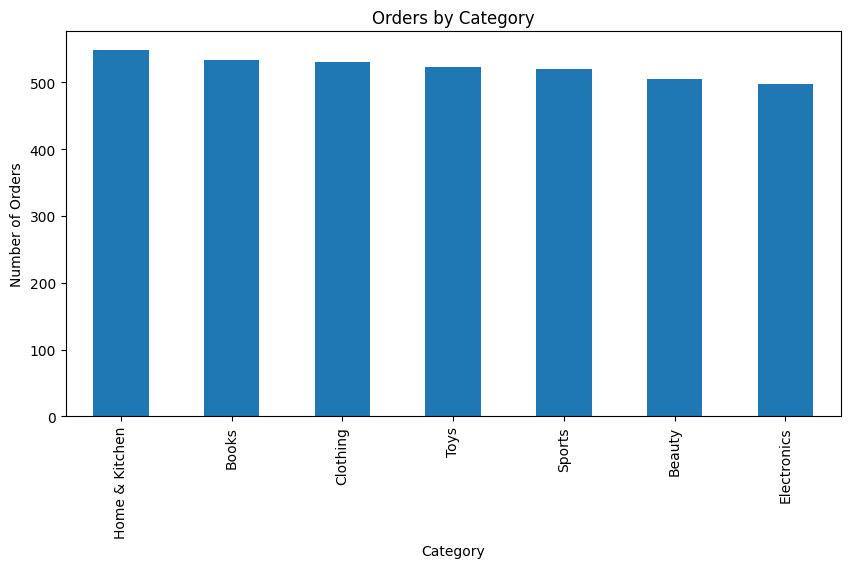

In [44]:
category_orders.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Orders by Category")
plt.ylabel("Number of Orders")
plt.show()

## Revenue by Category

In [45]:
category_revenue = (
    df.groupby('Category')['Final_Price(Rs.)']
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

Category
Clothing          115314.84
Books             111149.35
Home & Kitchen    110328.08
Sports            108518.79
Toys              107289.69
Beauty            104215.10
Electronics       100462.23
Name: Final_Price(Rs.), dtype: float64


## Average Selling Price by Category

In [46]:
avg_category_price = (
    df.groupby('Category')['Final_Price(Rs.)']
    .mean()
    .sort_values(ascending=False)
)

print(avg_category_price)

Category
Clothing          217.165424
Sports            208.689981
Books             208.144850
Beauty            206.366535
Toys              205.142811
Electronics       201.731386
Home & Kitchen    200.961894
Name: Final_Price(Rs.), dtype: float64


## Top 10 Products by Revenue

In [47]:
top_products = (
    df.groupby('Product_ID')['Final_Price(Rs.)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product_ID
5a4c2797-7    496.82
2a8fff8b-4    495.02
475d4cf1-c    493.04
e88dc97f-5    492.41
67d7c91c-b    491.70
128bb94a-4    487.06
28714133-6    486.79
585b0773-2    484.56
3be497cb-0    480.49
6390f2ea-8    479.63
Name: Final_Price(Rs.), dtype: float64


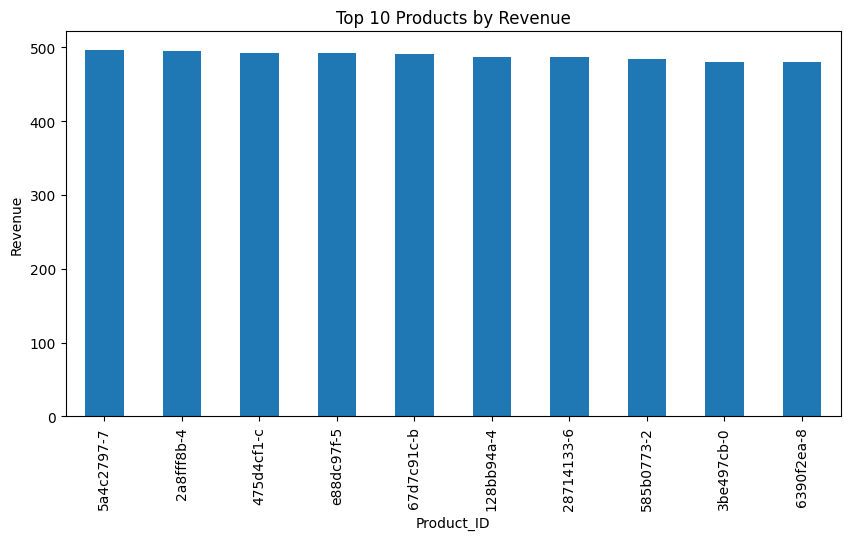

In [48]:
top_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

## Most Frequently Purchased Products

In [49]:
product_frequency = (
    df['Product_ID']
    .value_counts()
    .head(10)
)

print(product_frequency)

Product_ID
f414122f-e    1
fde50f9c-5    1
0d96fc90-3    1
964fc44b-d    1
d70e2fc6-e    1
0816ee12-5    1
d41e0b55-c    1
83b7dc04-5    1
87c9c896-1    1
31308875-b    1
Name: count, dtype: int64


## Category Contribution %

In [50]:
category_contribution = (
    df.groupby('Category')['Final_Price(Rs.)']
    .sum()
)

category_contribution = (
    category_contribution /
    category_contribution.sum()
) * 100

print(category_contribution.round(2))

Category
Beauty            13.76
Books             14.68
Clothing          15.23
Electronics       13.27
Home & Kitchen    14.57
Sports            14.33
Toys              14.17
Name: Final_Price(Rs.), dtype: float64


## Discount by Category

In [51]:
discount_category = (
    df.groupby('Category')['Discount (%)']
    .mean()
    .sort_values(ascending=False)
)

print(discount_category)

Category
Home & Kitchen    19.608379
Sports            19.326923
Electronics       19.267068
Books             19.035581
Beauty            18.475248
Toys              18.126195
Clothing          17.919021
Name: Discount (%), dtype: float64


## Revenue Distribution

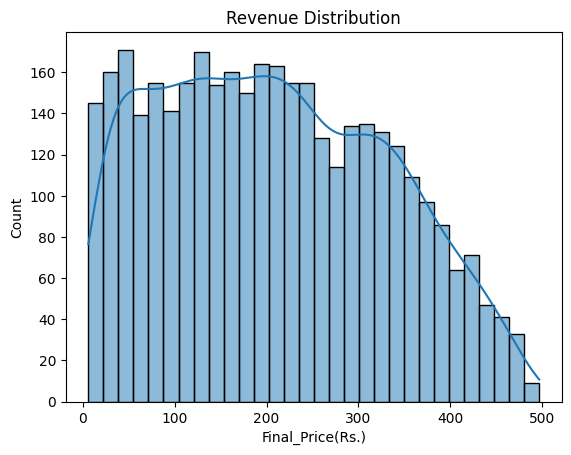

In [52]:
import seaborn as sns

sns.histplot(
    df['Final_Price(Rs.)'],
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")
plt.show()

## Identify High-Value Orders

In [55]:
threshold = df['Final_Price(Rs.)'].quantile(0.90)

high_value_orders = (
    df[df['Final_Price(Rs.)'] >= threshold]
)

print(high_value_orders.head())

     User_ID  Product_ID     Category  Price (Rs.)  Discount (%)  \
16  4578c08e  928b4b24-d         Toys       426.75             0   
38  0ae7336e  1dc3b1a0-4     Clothing       490.77            10   
44  f2e7bcc0  5e059f5f-7     Clothing       449.74            10   
48  d5daed7a  ee59d876-b       Beauty       479.19             0   
55  0b204db3  be68a8d8-7  Electronics       414.76             0   

    Final_Price(Rs.)    Payment_Method Purchase_Date  Year      Month  
16            426.75       Net Banking    2024-08-17  2024     August  
38            441.69               UPI    2024-08-03  2024     August  
44            404.77  Cash on Delivery    2024-09-15  2024  September  
48            479.19        Debit Card    2024-08-11  2024     August  
55            414.76        Debit Card    2024-06-30  2024       June  


# Time-Series & Seasonal Analysis

## Monthly Revenue Trend

In [56]:
monthly_revenue = (
    df.groupby('Month')['Final_Price(Rs.)']
    .sum()
)

monthly_revenue

Month
April        74365.13
August       71506.96
February     69186.34
January      69009.43
July         72798.23
June         64256.66
March        71325.40
May          68837.25
November     51915.08
October      76034.51
September    68043.09
Name: Final_Price(Rs.), dtype: float64

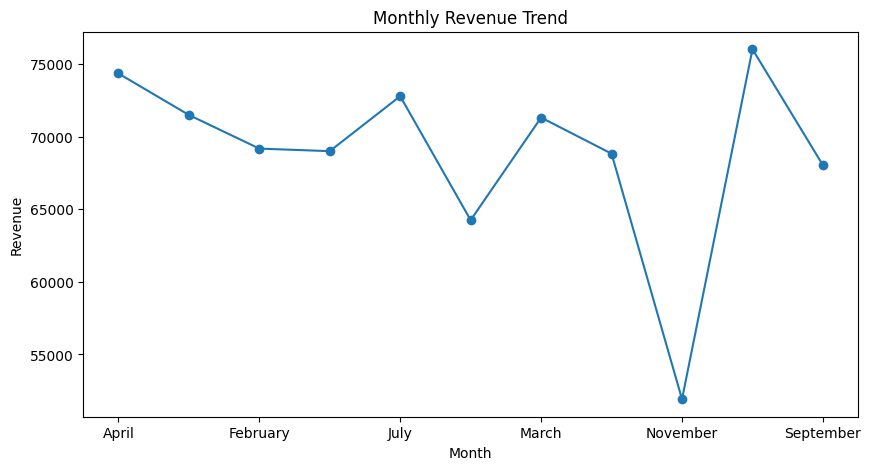

In [57]:
monthly_revenue.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

## Monthly Orders Trend

In [61]:
monthly_orders = (
    df.groupby('Month')
    .size()
)

monthly_orders

Month
April        362
August       344
February     308
January      340
July         346
June         323
March        355
May          333
November     245
October      362
September    342
dtype: int64

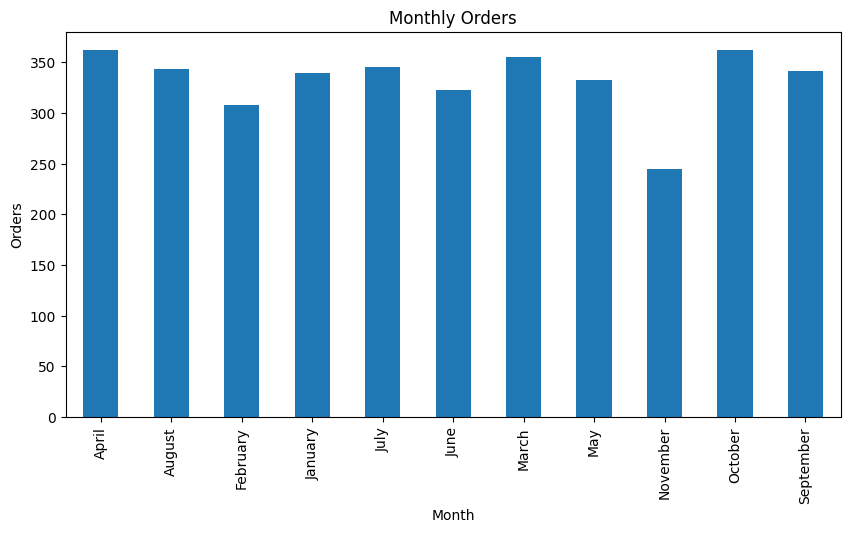

In [62]:
monthly_orders.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Monthly Orders")
plt.ylabel("Orders")
plt.show()

## Revenue by Year

In [63]:
yearly_revenue = (
    df.groupby('Year')['Final_Price(Rs.)']
    .sum()
)

yearly_revenue

Year
2024    757278.08
Name: Final_Price(Rs.), dtype: float64

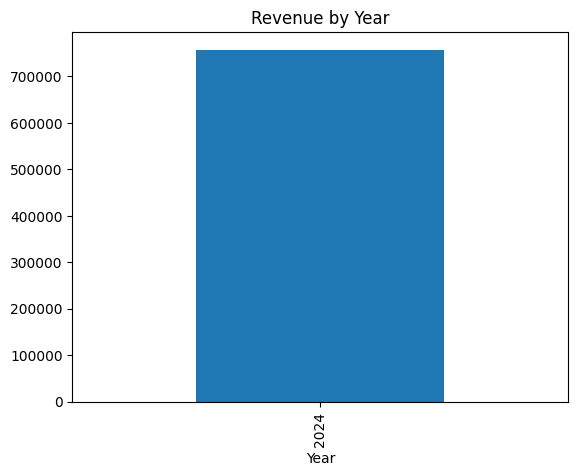

In [64]:
yearly_revenue.plot(
    kind='bar'
)

plt.title("Revenue by Year")
plt.show()

## Revenue by Day of Week

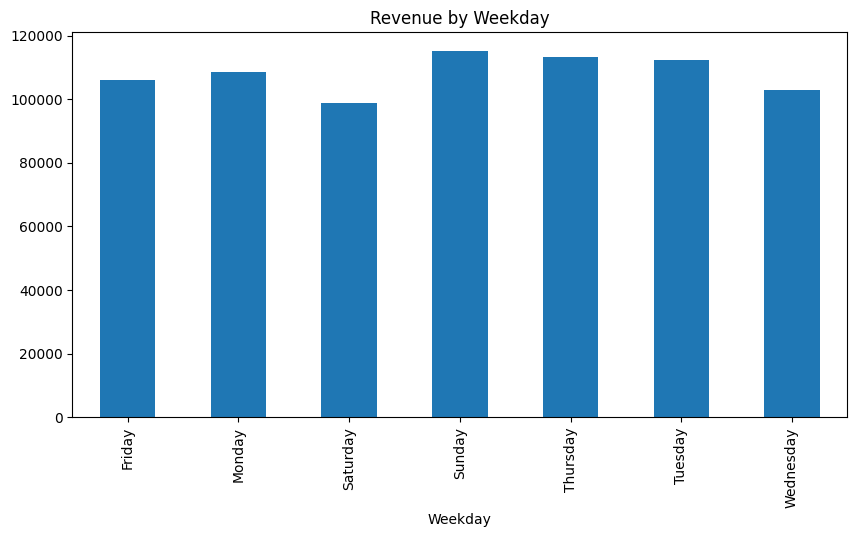

In [68]:
df['Weekday'] = (
    df['Purchase_Date']
    .dt.day_name()
)

weekday_revenue = (
    df.groupby('Weekday')['Final_Price(Rs.)']
    .sum()
)

weekday_revenue.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Revenue by Weekday")
plt.show()